In [1]:
import selfTracking

In [69]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as stat
import matplotlib.pyplot as plt

In [3]:
analyzer = selfTracking.Analyzer(data_directory="./data/")
analyzer.load_raw_data()
analyzer.raw_data.head()

,index,year,month,day,hour,min,sec,weekday,secStart,secSpent,active,Window,textWritten,keysPressed
0,0,2022,10,18,22,38,35,1,1.666126e+09,40245.224468,False,Domyślny ekran blokady systemu Windows,,
1,1,2022,10,19,9,49,20,2,1.666166e+09,4.585373,True,Domyślny ekran blokady systemu Windows,,space
2,2,2022,10,19,9,49,24,2,1.666166e+09,2.936318,True,,,
3,3,2022,10,19,9,49,27,2,1.666166e+09,5.210016,True,C:\Windows\system32\cmd.exe,,
4,4,2022,10,19,9,49,33,2,1.666166e+09,2.388092,True,D-separation - Google Chrome,,


In [5]:
analyzer.update_flag_file()
analyzer.assign_flags()
analyzer.raw_data[analyzer.raw_data.flag != ""].head()

C:\Users\PC\anaconda3\lib\site-packages\selfTracking\Analyzer.py:80: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  flag_data = pd.read_csv(self.flag_data, encoding="utf-8", sep=self.flag_separator, dtype='str', index_col=None)
C:\Users\PC\anaconda3\lib\site-packages\selfTracking\Analyzer.py:83: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  hand_flagged_windows = pd.read_csv(self.hand_flagged_windows, encoding="utf-8", sep=self.flag_separator, dtype='str', index_col=None)
C:\Users\PC\anaconda3\lib\site-packages\selfTracking\Analyzer.py:87: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char lon

,index,year,month,day,hour,min,sec,weekday,secStart,secSpent,active,Window,textWritten,keysPressed,flag
187,187,2022,10,19,22,39,31,2,1.666212e+09,3.398877,True,PyCharm User Agreement,,,coding
190,190,2022,10,19,22,39,45,2,1.666212e+09,29.008390,True,Welcome to PyCharm,,,coding
202,202,2022,10,19,22,49,20,2,1.666213e+09,25.961823,True,python - How do I use Anaconda packages in PyC...,,,coding
206,206,2022,10,19,22,50,8,2,1.666213e+09,1.315944,True,python - How do I use Anaconda packages in PyC...,t,right ctrlt,coding
220,220,2022,10,19,22,52,55,2,1.666213e+09,1.895729,True,Configure a Conda virtual environment | PyChar...,,,coding


In [8]:
data = analyzer.make_time_series([selfTracking.letters_per_second, selfTracking.words_per_second, selfTracking.resting])
data.head()

,index,letters_per_second,words_per_second,resting
1666165760,0.076423,0.016667,0.016667,0.0
1666165820,0.000000,0.000000,0.000000,0.0
1666165880,0.000000,0.000000,0.000000,0.0
1666165940,0.000000,0.000000,0.000000,0.0
1666166000,0.000000,0.000000,0.000000,0.0


first need to get a column that represents time, but can also be interpreted by pandas

In [72]:
def get_time(sec):
    sec = sec.iloc[0]
    time = dt.datetime.fromtimestamp( sec ).time()
    return time.hour*100 + time.minute

In [73]:
data["hour"] = data.apply( get_time  , axis = 1)

now to get a data of 'mean' for each day

In [74]:
aaa = data.groupby( "hour" ).mean()

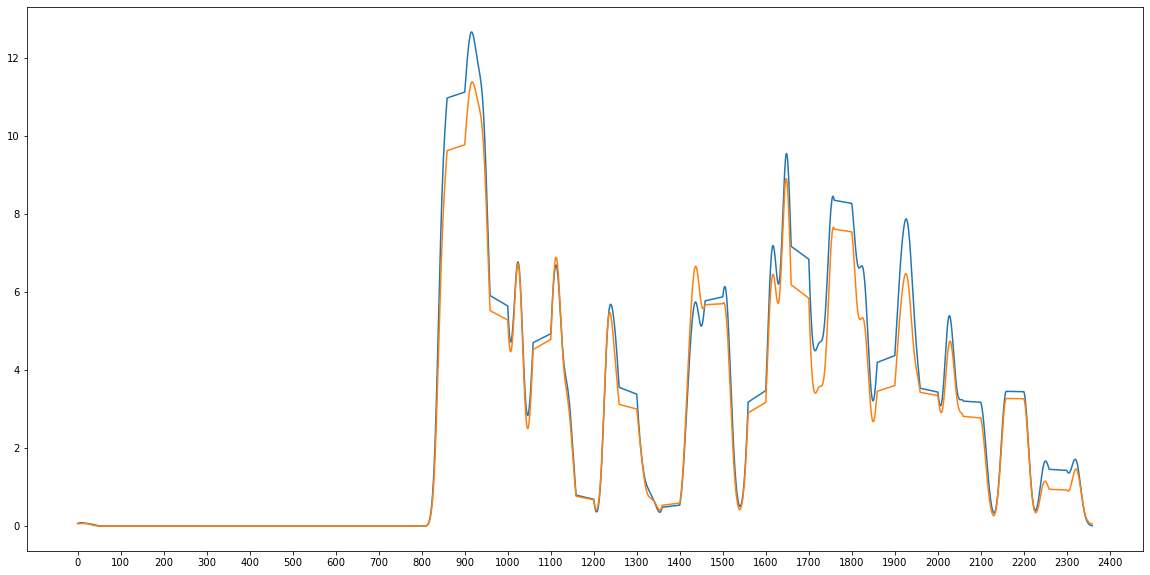

In [75]:
fig, ax = plt.subplots()

kernel = [ stat.norm.pdf(i*0.1) for i in range(-30,30)]
smoothed_lps = np.convolve( aaa.letters_per_second*10 , kernel , "same" )
smoothed_wpd = np.convolve( aaa.words_per_second*60 , kernel , "same" )

ax.plot( aaa.index , smoothed_lps )
ax.plot( aaa.index , smoothed_wpd )
#ax.plot( aaa.index ,  aaa.letters_per_second*10 )
#ax.plot( aaa.index , aaa.words_per_second*60  )
fig.set_size_inches(20,10)

ax.set_xticks( [ i*100 for i in range(25) ] )


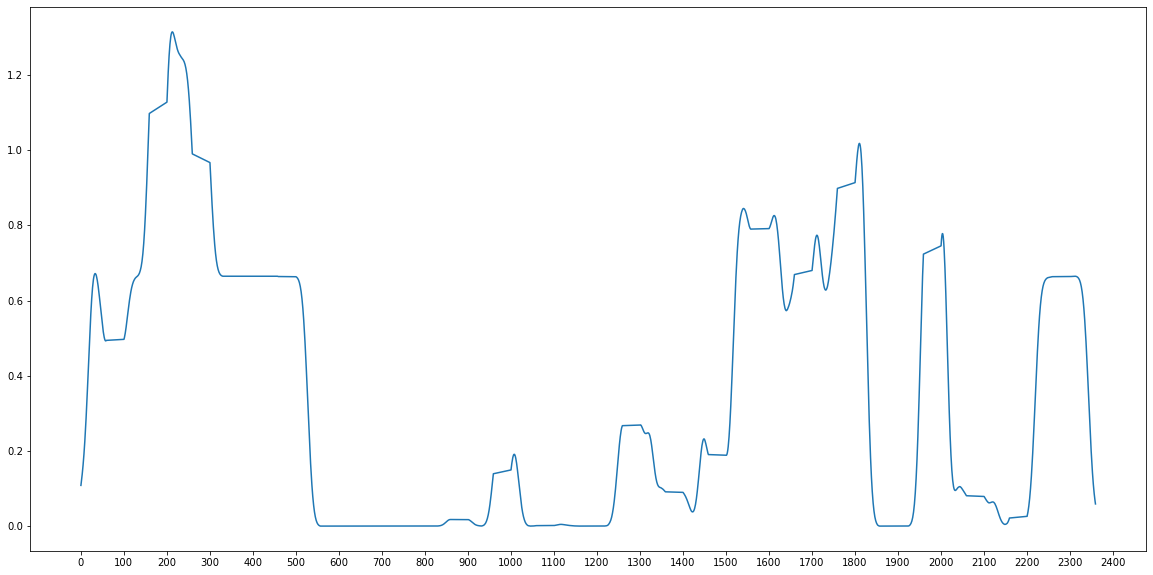

In [87]:
fig, ax = plt.subplots()


kernel = [ stat.norm.pdf(i*0.1) for i in range(-30,30)]
smoothed_resting = np.convolve( aaa.resting , kernel , "same" )

ax.plot( aaa.index , smoothed_resting)
fig.set_size_inches(20,10)

ax.set_xticks( [ i*100 for i in range(25) ] )


In [83]:
print(aaa.resting.to_string())

hour
0       0.066667
1       0.036836
2       0.050012
3       0.036452
4       0.000000
5       0.000000
6       0.000000
7       0.000000
8       0.000000
9       0.000000
10      0.001294
11      0.000000
12      0.000000
13      0.000000
14      0.022947
15      0.066667
16      0.001719
17      0.000000
18      0.062558
19      0.066667
20      0.066667
21      0.066667
22      0.102938
23      0.085227
24      0.118564
25      0.133333
26      0.108900
27      0.066667
28      0.066667
29      0.079153
30      0.080211
31      0.029706
32      0.066667
33      0.066120
34      0.066406
35      0.066667
36      0.066667
37      0.066667
38      0.066667
39      0.066667
40      0.066667
41      0.066364
42      0.066667
43      0.066667
44      0.066667
45      0.066667
46      0.066667
47      0.065158
48      0.066667
49      0.066667
50      0.045070
51      0.036437
52      0.066412
53      0.061803
54      0.000798
55      0.014392
56      0.023616
57      0.008124
58      0